In [39]:
import pm4py
#from synthetical_log_generation.log_generator import create_translucent_event_log
from pm4py.objects.conversion.log import converter as log_converter
import pickle
import os
import pandas as pd
import numpy as np
from Soccer_OCEL.idsse_import import get_games
import Soccer_OCEL.isolation_forest as isolation_forest
import Soccer_OCEL.utils as utils

#from translucent_discovery.translucent_inductive_miner.translucent_base import discover_petri_net
#from translucent_precision.main import translucent_precision_score

from pm4py.algo.evaluation import algorithm as general_evaluation
from pm4py.algo.transformation.log_to_features.variants import trace_based
import pandas as pd
from sklearn.ensemble import IsolationForest
from pm4py.algo.label_splitting import algorithm as label_splitter

{'avg': np.float64(0.1276901422153309), 'anonmaly_relative_frequency': np.float64(0.004477757227684221)}
Found 138 traces
                   ano_traces_with_event  event_count_in_ano_log  \
Cross_Received                        23                      23   
Play_Cross                            46                      46   
TacklingGame                         138                     276   
Play_Pass_2                           23                      23   
Play_Pass_0                          115                     598   
Play_Pass_1                          138                     575   
Pass_Intercepted                      92                      92   
Pass_Received                        138                     966   
ThrowIn_Play_Pass                     23                      23   
OtherBallAction                       69                     138   

                   event_count_in_log  trace_fraction_in_anomalies  
Cross_Received                    276                     0.

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


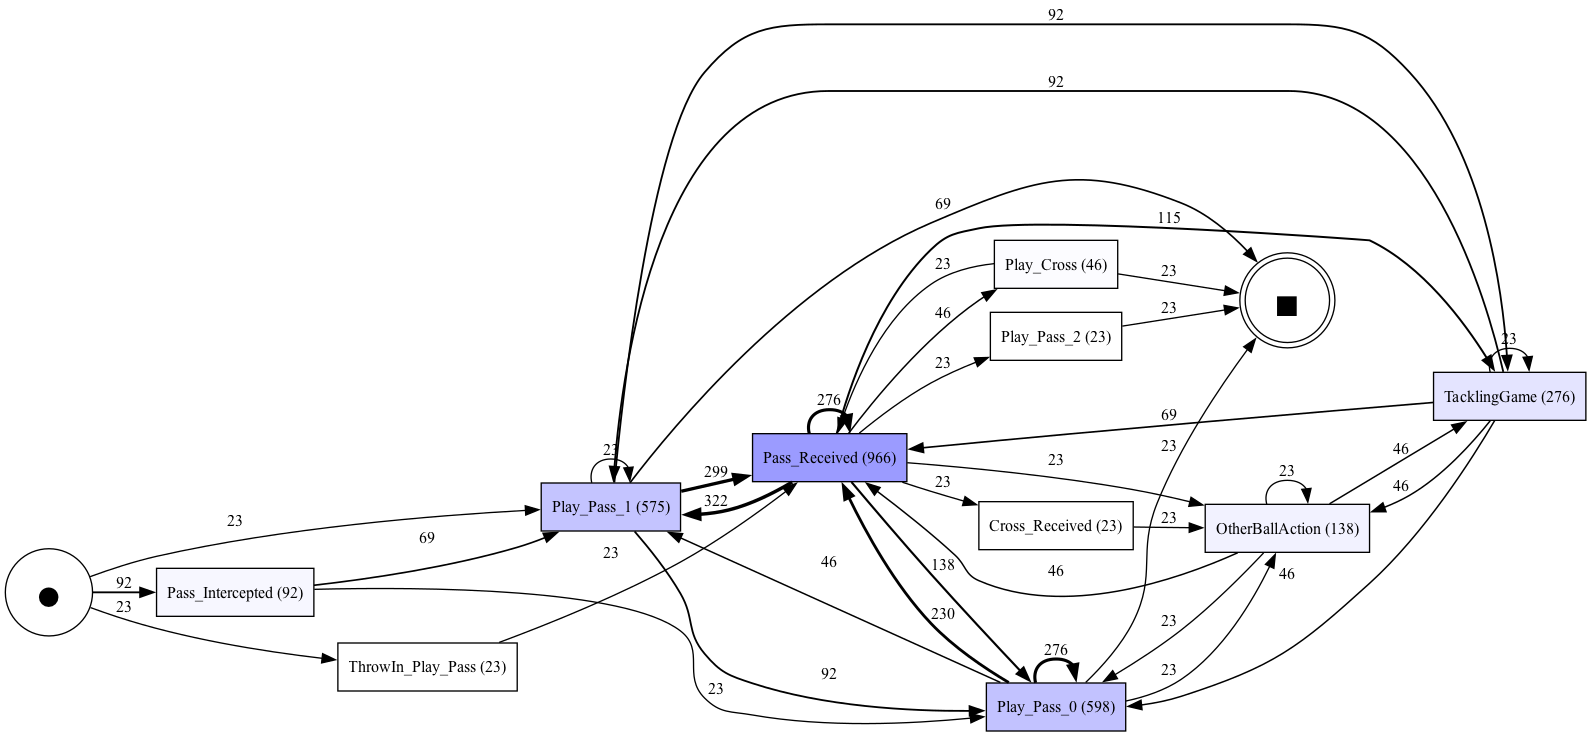

In [ ]:
path='data/28196177'
#games=get_games(path)#load all 7 games
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('/Users/vitochan/Documents/phd/Projects/Soccer/IDSSE_notebooks/output'
                           ,'output_pkl',f"GameData_{Game}_withposition.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GD_loaded = utils.formatting(GD_loaded)
        all_games.append(GD_loaded)
logs=[game.events for game in all_games]
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
# log = pm4py.convert_to_event_log(log_df)
#log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL)

log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL,
                                parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"
                                                                   ]})
shot_events=log_df[(log_df['concept:name'].str.contains('ShotAt'))]
log_df = log_df[~log_df['case:concept:name'].isin(shot_events['case:concept:name'])]
log_df = log_df[log_df['attribute:team']=='Home']
keeps=['concept:name','Player','ball','case:concept:name','time:timestamp','attribute:x'
       ,'attribute:y','attribute:enabled','attribute:gameclock'
       ,'attribute:session','attribute:frame','attribute:team','attribute:outcome'
       ,'attribute:game', 'role', 'zone','side', 'position']
# for col in log_df.columns:
#     #print(col)
#     check=input(col)
#     if len(check)>0:
#         keeps.append(col)
for col in log_df.columns:
    if col not in keeps:
        log_df.drop(columns=col, inplace=True)
df_ball = log_df[log_df['ball'].notna()].copy()
df_no_ball = log_df[log_df['ball'].isna()].copy()

df_no_ball['case:concept:name']=df_no_ball['case:concept:name']+df_no_ball['Player']

players = df_no_ball['Player'].dropna().unique()

dfs = []
for p in players:
    df_copy = df_ball.copy()
    df_copy['case:concept:name'] = df_copy['case:concept:name'] + "_" + p
    dfs.append(df_copy)

log_df = pd.concat(dfs + [df_no_ball], ignore_index=True).sort_values(['attribute:session', 'time:timestamp']).reset_index(drop=True)

#log_df['case:concept:name']=log_df['case:concept:name']+log_df['Player']
log_df=log_df[~log_df['case:concept:name'].isna()].reset_index(drop=True)
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)

# ##event based
# anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
# dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
# pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode, variant='trace', n_estimators=500)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

{'avg': np.float64(0.1564986307363444), 'anonmaly_relative_frequency': np.float64(0.00016786973308712439)}
Found 1 traces
                    ano_traces_with_event  event_count_in_ano_log  \
Central Transition                      1                       1   
Wing Transition                         1                       1   
Play_Pass_1                             1                       2   
Play_Pass_0                             1                       2   
Pass_Received                           1                       4   

                    event_count_in_log  trace_fraction_in_anomalies  
Central Transition                 548                     0.001845  
Wing Transition                    637                     0.001582  
Play_Pass_1                        859                     0.001287  
Play_Pass_0                        954                     0.001282  
Pass_Received                     1721                     0.000759  


/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


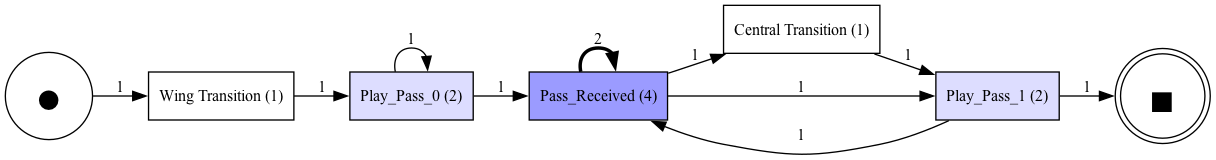

In [84]:
path='data/28196177'
#games=get_games(path)#load all 7 games
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('/Users/vitochan/Documents/phd/Projects/Soccer/IDSSE_notebooks/output'
                           ,'output_pkl',f"GameData_{Game}_withposition.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GD_loaded = utils.formatting(GD_loaded)
        all_games.append(GD_loaded)
logs=[game.events for game in all_games]
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
# log = pm4py.convert_to_event_log(log_df)
#log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL)

log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL,
                                parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"
                                                                   ]})
shot_events=log_df[(log_df['concept:name'].str.contains('ShotAt'))]
log_df = log_df[~log_df['case:concept:name'].isin(shot_events['case:concept:name'])]
log_df = log_df[log_df['attribute:team']=='Home']
keeps=['concept:name','Player','ball','case:concept:name','time:timestamp','attribute:x'
       ,'attribute:y','attribute:enabled','attribute:gameclock'
       ,'attribute:session','attribute:frame','attribute:team','attribute:outcome'
       ,'attribute:game', 'role', 'zone','side', 'position']
# for col in log_df.columns:
#     #print(col)
#     check=input(col)
#     if len(check)>0:
#         keeps.append(col)
for col in log_df.columns:
    if col not in keeps:
        log_df.drop(columns=col, inplace=True)
log_df['case:concept:name']=log_df['case:concept:name']+log_df['Player']
log_df=log_df[~log_df['case:concept:name'].isna()].reset_index(drop=True)
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)

# ##event based
# anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
# dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
# pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode, variant='trace', n_estimators=300)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

In [80]:
np.unique([id.split('_')[-1].split('-')[-1] for id in np.unique(anomalies['case:concept:name'])], return_counts=True)

(array(['0000F8', '002GM1', 'J0130T', 'J01H9X', 'J01KJ5'], dtype='<U6'),
 array([ 23, 115,  23,  23,  46]))

In [106]:
path='data/28196177'
#games=get_games(path)#load all 7 games
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('/Users/vitochan/Documents/phd/Projects/Soccer/IDSSE_notebooks/output'
                           ,'output_pkl',f"GameData_{Game}_withposition.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GD_loaded = utils.formatting(GD_loaded)
        all_games.append(GD_loaded)
logs=[game.events for game in all_games]
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
# log = pm4py.convert_to_event_log(log_df)
#log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL)

log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL,
                                parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"
                                                                   ]})
shot_events=log_df[(log_df['role'].str.contains('ShotAt'))]
log_df = log_df[~log_df['case:concept:name'].isin(shot_events['case:concept:name'])]

log_df=log_df[(log_df['concept:name']=='Forward')]
#log_df = log_df[~log_df['case:concept:name'].isin(role_events['case:concept:name'])]

log_df = log_df[log_df['attribute:team']=='Home']
keeps=['concept:name','Player','ball','case:concept:name','time:timestamp','attribute:x'
       ,'attribute:y','attribute:enabled','attribute:gameclock'
       ,'attribute:session','attribute:frame','attribute:team','attribute:outcome'
       ,'attribute:game', 'role', 'zone','side', 'position']
# for col in log_df.columns:
#     #print(col)
#     check=input(col)
#     if len(check)>0:
#         keeps.append(col)
for col in log_df.columns:
    if col not in keeps:
        log_df.drop(columns=col, inplace=True)

log_df['case:concept:name']=log_df['case:concept:name']+log_df['Player']
log_df=log_df[~log_df['case:concept:name'].isna()].reset_index(drop=True)
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)

##trace based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode, variant='trace', n_estimators=200)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:15: FutureWarning: 'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.
  dict_columns = [col for col in df.columns if df[col].apply(lambda x: isinstance(x, dict)).any()]


ValueError: at least one array or dtype is required

In [ ]:
np.unique(anomalies['case:concept:name'])

In [ ]:
path='data/28196177'
#games=get_games(path)#load all 7 games
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('/Users/vitochan/Documents/phd/Projects/Soccer/IDSSE_notebooks/output'
                           ,'output_pkl',f"GameData_{Game}_withposition.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GD_loaded = utils.formatting(GD_loaded)
        all_games.append(GD_loaded)
logs=[game.events for game in all_games]
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
# log = pm4py.convert_to_event_log(log_df)
#log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL)

log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL,
                                parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"
                                                                   ]})
shot_events=log_df[(log_df['role'].str.contains('ShotAt'))]
log_df = log_df[~log_df['case:concept:name'].isin(shot_events['case:concept:name'])]

role_events=log_df[(log_df['concept:name']=='Midfielder')]
log_df = log_df[~log_df['case:concept:name'].isin(role_events['case:concept:name'])]

log_df = log_df[log_df['attribute:team']=='Home']
keeps=['concept:name','Player','ball','case:concept:name','time:timestamp','attribute:x'
       ,'attribute:y','attribute:enabled','attribute:gameclock'
       ,'attribute:session','attribute:frame','attribute:team','attribute:outcome'
       ,'attribute:game', 'role', 'zone','side', 'position']
# for col in log_df.columns:
#     #print(col)
#     check=input(col)
#     if len(check)>0:
#         keeps.append(col)
for col in log_df.columns:
    if col not in keeps:
        log_df.drop(columns=col, inplace=True)

log_df['case:concept:name']=log_df['case:concept:name']+log_df['Player']
log_df=log_df[~log_df['case:concept:name'].isna()].reset_index(drop=True)
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)

# ##event based
# anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
# dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
# pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode, variant='trace', n_estimators=200)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

{'avg': np.float64(0.15690754735604973), 'anonmaly_relative_frequency': np.float64(0.0)}
Found 0 traces
                                 ano_traces_with_event  \
concept:name                                             
Pass_Received                                        0   
Offside                                              0   
ShotWide                                             0   
Cross_Received                                       0   
OutSubstitution                                      0   
CornerKick_Play_Cross                                0   
SavedShot                                            0   
BlockedShot                                          0   
ThrowIn_Play_Cross                                   0   
Caution                                              0   
Scored                                               0   
FreeKick_Play_Cross                                  0   
KickOff_Play_Pass                                    0   
Run                       

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:124: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  case_count_ano_df = case_count_ano_df.fillna(0)


ValueError: min() arg is an empty sequence

{'avg': np.float64(0.15645109317853648), 'anonmaly_relative_frequency': np.float64(0.0001527417137620284)}
Found 1 traces
                    ano_traces_with_event  event_count_in_ano_log  \
Central Transition                      1                       1   
Wing Transition                         1                       1   
Play_Pass_1                             1                       2   
Play_Pass_0                             1                       2   
Pass_Received                           1                       4   

                    event_count_in_log  trace_fraction_in_anomalies  
Central Transition                 588                     0.001724  
Wing Transition                    685                     0.001473  
Play_Pass_1                        947                     0.001174  
Play_Pass_0                       1059                     0.001152  
Pass_Received                     1894                     0.000689  


/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


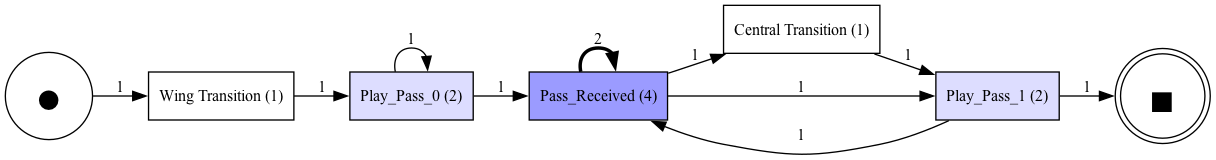

In [ ]:
path='data/28196177'
#games=get_games(path)#load all 7 games
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('/Users/vitochan/Documents/phd/Projects/Soccer/IDSSE_notebooks/output'
                           ,'output_pkl',f"GameData_{Game}_withposition.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GD_loaded = utils.formatting(GD_loaded)
        all_games.append(GD_loaded)
logs=[game.events for game in all_games]
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
# log = pm4py.convert_to_event_log(log_df)
#log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL)

log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL,
                                parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"
                                                                   ]})
shot_events=log_df[(log_df['role'].str.contains('ShotAt'))]
log_df = log_df[~log_df['case:concept:name'].isin(shot_events['case:concept:name'])]

role_events=log_df[(log_df['concept:name']=='Defender')]
log_df = log_df[~log_df['case:concept:name'].isin(role_events['case:concept:name'])]

log_df = log_df[log_df['attribute:team']=='Home']
keeps=['concept:name','Player','ball','case:concept:name','time:timestamp','attribute:x'
       ,'attribute:y','attribute:enabled','attribute:gameclock'
       ,'attribute:session','attribute:frame','attribute:team','attribute:outcome'
       ,'attribute:game', 'role', 'zone','side', 'position']
# for col in log_df.columns:
#     #print(col)
#     check=input(col)
#     if len(check)>0:
#         keeps.append(col)
for col in log_df.columns:
    if col not in keeps:
        log_df.drop(columns=col, inplace=True)

log_df['case:concept:name']=log_df['case:concept:name']+'_'+log_df['Player']
log_df=log_df[~log_df['case:concept:name'].isna()].reset_index(drop=True)
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)

# ##event based
# anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
# dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
# pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode, variant='trace', n_estimators=200)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

In [102]:
np.unique(anomalies['case:concept:name'])

array(['J03WR9_Home_82DFL-OBJ-002GM1'], dtype=object)

In [ ]:
GD_loaded.team_sheets_df.query('pID=="DFL-OBJ-002GM1"')##offensive left midfield

,player,position,team,jID,pID,tID,Home_Away
11,Kristoffer Peterson,OLM,Fortuna Düsseldorf,7,DFL-OBJ-002GM1,DFL-CLU-00000P,Home


In [94]:
path='data/28196177'
#games=get_games(path)#load all 7 games
games=['J03WQQ', 'J03WR9', 'J03WPY', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf games
#games=['J03WQQ', 'J03WOH', 'J03WOY'] #Fortuna Düsseldorf, won game
#games=['J03WR9', 'J03WPY'] #Fortuna Düsseldorf lost game
all_games=[]
for Game in games:
    with open(os.path.join('/Users/vitochan/Documents/phd/Projects/Soccer/IDSSE_notebooks/output'
                           ,'output_pkl',f"GameData_{Game}_withposition.pkl"), "rb") as f:
        GD_loaded = pickle.load(f)
        GD_loaded = utils.formatting(GD_loaded)
        all_games.append(GD_loaded)
logs=[game.events for game in all_games]
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
# log = pm4py.convert_to_event_log(log_df)
#log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL)

log_df = label_splitter.apply(log_df, variant=label_splitter.Variants.CONTEXTUAL,
                                parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"
                                                                   ]})

anomaly_case=log_df[log_df['case:concept:name']=='J03WR9_Home_82']

/Users/vitochan/Documents/phd/Projects/Soccer/.venv/lib/python3.11/site-packages/pm4py/algo/discovery/dfg/adapters/pandas/df_statistics.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[start_timestamp_key] = df[timestamp_key]


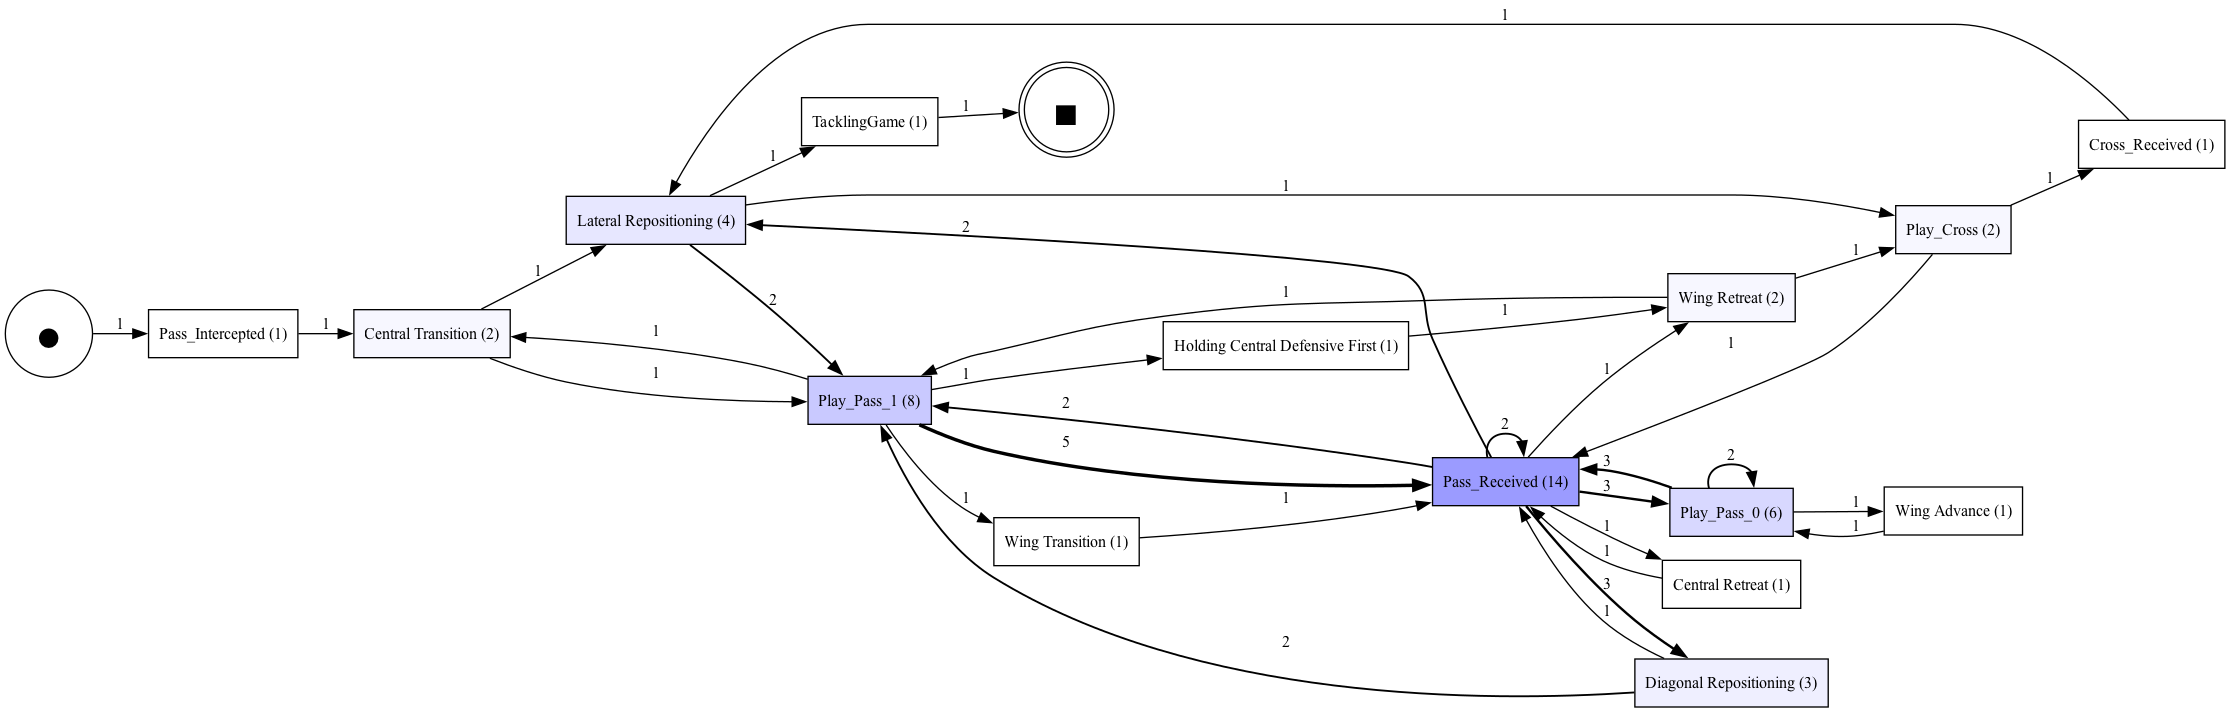

In [96]:
dfg, start_activities, end_activities = pm4py.discover_dfg(anomaly_case)
pm4py.view_dfg(dfg, start_activities, end_activities)

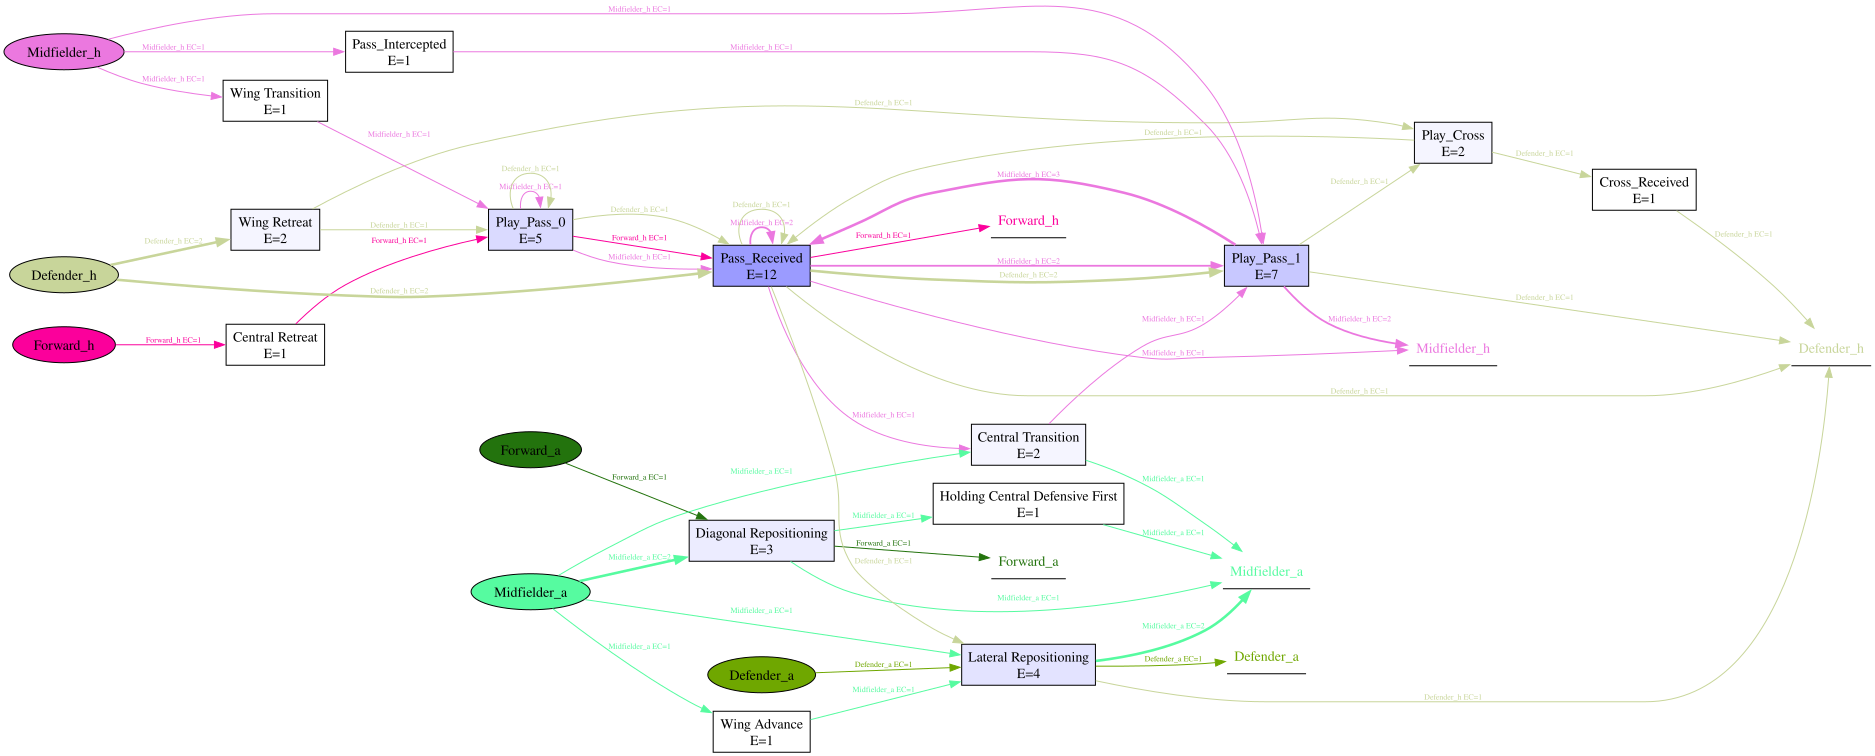

In [98]:
# convert to ocel
from pm4py.objects.ocel.util.log_ocel import log_to_ocel_multiple_obj_types
ocel= log_to_ocel_multiple_obj_types(anomaly_case, activity_column='concept:name'
                                        , timestamp_column='time:timestamp'
                                        , obj_types=[#'case:concept:name'
                                                     #'attacking_team', 'defending_team'
                                                     #'ball',
                                                     "Forward_h", "Midfielder_h", "Defender_h", "Goalkeeper_h"
                                                     ,"Forward_a", "Midfielder_a", "Defender_a", "Goalkeeper_a"
                                                     #,'Team','Player','Session', 'case:concept:name'
                                                     ]
                                        ,additional_event_attributes=['attribute:enabled'
                                                                    , 'attribute:x', 'attribute:y'
                                                                    , 'attribute:session', 'attribute:team'
                                                                    ])
dfg=pm4py.ocel.discover_ocdfg(ocel,business_hours=True)
pm4py.visualization.ocel.ocdfg.visualizer.apply(dfg)


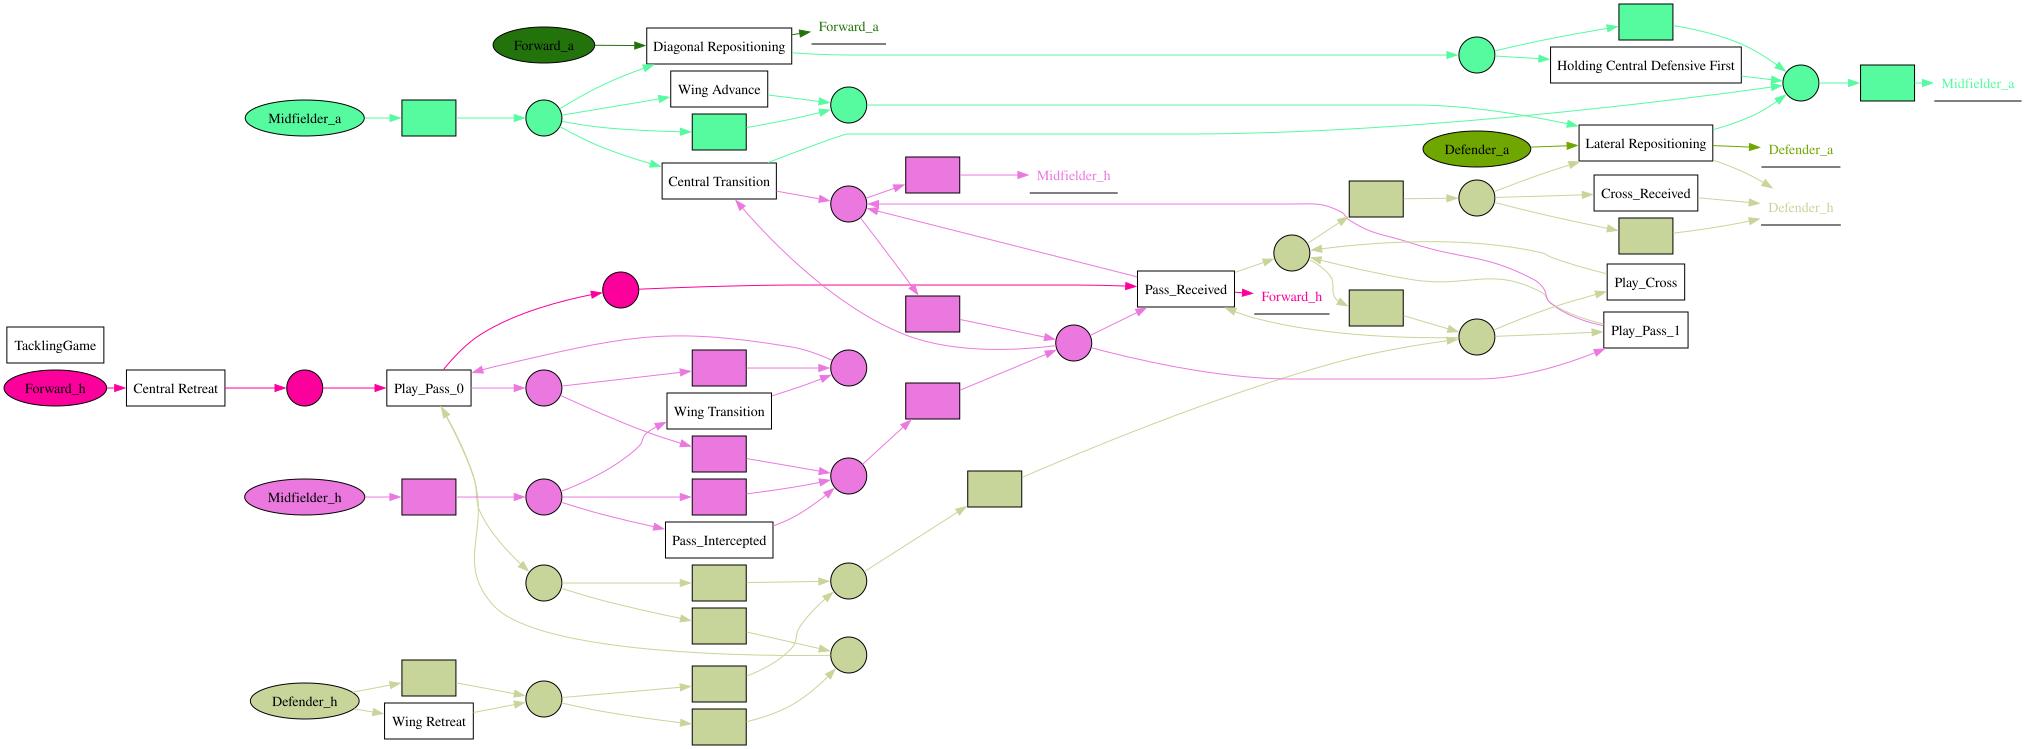

In [99]:
pn=pm4py.ocel.discover_oc_petri_net(ocel)
pm4py.visualization.ocel.ocpn.visualizer.apply(pn)

In [65]:
len(np.unique(anomalies['case:concept:name']))

115

In [ ]:
##pick a single player a5 #try the position event, ball event maybe only start and end, and only those that the player is involved
##h5 suppose to defend a5

In [4]:
##home
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
Home_df = log_df[log_df['case:concept:name'].str.contains('Home')]
log_df = label_splitter.apply(Home_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)
##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlis, case_count_anot=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

Dropped dict columns: ['attribute:qualifier']


/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(


{'avg': np.float64(0.15053410535674216), 'anonmaly_relative_frequency': np.float64(0.0)}
Found 0 traces
                                 ano_traces_with_event  \
concept:name                                             
Pass_Received                                        0   
Lateral Repositioning                                0   
BlockedShot                                          0   
CornerKick_Play_Cross                                0   
ThrowIn_Play_Cross                                   0   
Caution                                              0   
Offside                                              0   
Scored                                               0   
FreeKick_Play_Cross                                  0   
PenaltyNotAwarded                                    0   
RefereeBall                                          0   
KickOff_Play_Pass                                    0   
SpectacularPlay                                      0   
Run                       

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:124: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  case_count_ano_df = case_count_ano_df.fillna(0)


ValueError: min() arg is an empty sequence

In [ ]:
##shots
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
shot_events=log_df[(log_df['concept:name'].str.contains('ShotAt'))]
shot_df = log_df[log_df['case:concept:name'].isin(shot_events['case:concept:name'])]
log_df = label_splitter.apply(shot_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)
##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlis, case_count_anot=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

Dropped dict columns: ['attribute:qualifier']


/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(


{'avg': np.float64(0.14364237414538708), 'anonmaly_relative_frequency': np.float64(0.0)}
Found 0 traces
                                 ano_traces_with_event  \
concept:name                                             
Pass_Received                                        0   
Lateral Repositioning                                0   
Scored                                               0   
Holding Wing Defensive First                         0   
ThrowIn_Play_Pass                                    0   
CornerKick_Play_Cross                                0   
BallClaiming                                         0   
FreeKick_Play_Pass                                   0   
Run                                                  0   
Cross_Intercepted                                    0   
GoalKick_Play_Pass                                   0   
OtherShot                                            0   
PossessionLossBeforeGoal                             0   
FreeKick_ShotAtGoal       

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:124: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  case_count_ano_df = case_count_ano_df.fillna(0)


ValueError: min() arg is an empty sequence

In [ ]:
##shots
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
shot_events=log_df[(log_df['concept:name'].str.contains('ShotAt'))]
shot_df = log_df[log_df['case:concept:name'].isin(shot_events['case:concept:name'])]
log_df = label_splitter.apply(shot_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)
##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlis, case_count_anot=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

Dropped dict columns: ['attribute:qualifier']


/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(
/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[[f"{col}_0", f"{col}_1"]] = col_series.apply(


{'avg': np.float64(0.14315914134148774), 'anonmaly_relative_frequency': np.float64(0.0)}
Found 0 traces
                                 ano_traces_with_event  \
concept:name                                             
Pass_Received                                        0   
Lateral Repositioning                                0   
Scored                                               0   
Holding Wing Defensive First                         0   
ThrowIn_Play_Pass                                    0   
CornerKick_Play_Cross                                0   
BallClaiming                                         0   
FreeKick_Play_Pass                                   0   
Run                                                  0   
Cross_Intercepted                                    0   
GoalKick_Play_Pass                                   0   
OtherShot                                            0   
PossessionLossBeforeGoal                             0   
FreeKick_ShotAtGoal       

/Users/vitochan/Documents/phd/Projects/Soccer/Soccer_OCEL/isolation_forest.py:124: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  case_count_ano_df = case_count_ano_df.fillna(0)


ValueError: min() arg is an empty sequence

In [ ]:
##non shots
log_df=pd.concat(logs).sort_values('time:timestamp').reset_index(drop=True)
shot_events=log_df[(log_df['concept:name'].str.contains('Shot'))]
no_shot_df = log_df[~log_df['case:concept:name'].isin(shot_events['case:concept:name'])]
log_df = label_splitter.apply(no_shot_df, variant=label_splitter.Variants.CONTEXTUAL,
                                 parameters={#"prefix_length": 1, "suffix_length": 1,
                                             "target_activities": ["Play_Pass","Play_Cross",
                                                                   "Play_Pass_Intercepted", "Play_Pass_Received",
                                                                   "Play_Cross_Received", "Play_Cross_Intercepted"]})
log_df_encode, encoders=isolation_forest.encode_non_numeric(log_df)
##event based
anomalies, log_features_df, case_idlist, case_count_ano=isolation_forest.find_anom(log_df_encode)
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

##trace based
anomalies, log_features_df, case_idlis, case_count_anot=isolation_forest.find_anom(log_df_encode, variant='trace')
dfg, start_activities, end_activities = pm4py.discover_dfg(anomalies)
pm4py.view_dfg(dfg, start_activities, end_activities)

KeyboardInterrupt: 

In [22]:
np.unique(anomalies['Player'], return_counts=True)

(array([  0,   2,   3,   5,   6,   7,   8,   9,  10,  11,  12,  13,  15,
         16,  17,  18,  21,  22,  26,  27,  28,  29,  30,  31,  32,  33,
         34,  35,  36,  37,  38,  39,  40,  41,  43,  44,  45,  46,  47,
         48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  60,  61,
         62,  63,  64,  65,  67,  68,  69,  70,  72,  73,  74,  75,  76,
         77,  78,  79,  80,  81,  83,  85,  86,  87,  88,  89,  90,  91,
         92,  94,  95,  96,  98,  99, 100, 101, 102, 103, 104, 105, 106,
        107, 109, 110, 111, 112, 113, 114, 115, 116, 117, 119, 120, 121,
        122, 124, 125, 126, 127, 129, 130, 131, 132, 133, 134, 135, 136,
        137, 139, 140, 141, 143, 144, 145, 146, 148, 149, 151, 152, 159,
        160, 162, 163, 164]),
 array([ 1,  6,  3,  1,  2, 25,  1, 15,  3, 17, 24,  1,  9,  5, 27, 22, 13,
         7,  7, 12,  4, 13, 13, 10,  4, 19, 20, 23, 11,  7,  6, 29,  5, 10,
         5,  9,  7, 11, 10,  2,  6,  2, 26, 21,  5,  5, 10, 12,  6, 13,  5,
        24, 

In [23]:
np.unique(anomalies['role'], return_counts=True)

(array([0, 1, 2, 3, 4]), array([528, 138,  54, 618, 166]))